---
format: 
    html:
      toc: true
title: "Variant calling and VCF files"
author: "Samuele Soraggi, Manuel Peral-Vázquez, Lavinia Fechete, Stig U Andersen, Mikkel H Schierup"
date-modified: last-modified
title-block-banner: true
bibliography: images/bibliography.bib
---

:::{.callout-note title="Tutorial description"}

This tutorial will cover the steps for performing Variant calling and working on the resulting VCF file format. We will be using the Hifi and RNA-seq mapping data obtained from Galaxy. At the end of this tutorial you will be able to:

- call variants using alignment files
- extract data from `VCF` files using `Python`
- filter and count variants 

:::

Import the necessary Python libraries:

In [1]:
import pandas
import allel
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

Some of the commands used in the course are functions we implement to simplify reading the code of this course. Mostly, those are commands requiring lines of code that would not add anything to your learning curve (management of plots, trivial calculations, few management of the notebook layout). However, you are free to look at the code into the file `../Scripts/pythonScripts.py` and to reuse our code in your own work (citing our course).

In [2]:
%run ../Scripts/pythonScripts.py

Create a folder for the data necessary to VCF data analysis

In [3]:
%%bash
mkdir -p Data_for_VCF_analysis

# Use the `bam` files generated from the alignment of raw reads

We will use alignment data from the previous session. You should have the following BAM files in the `results` folder:

- `HIFI_contig_1.bam` — HiFi reads mapped to Contig 1
- `HIFI_contig_2.bam` — HiFi reads mapped to Contig 2
- `HIFI_contig_1_2_asm20.bam` — HiFi reads mapped to both contigs
- `RNA_S10_merged.bam` — S10 RNA-seq reads mapped to both contigs (merged)
- `RNA_TI_merged.bam` — Tienshan RNA-seq reads mapped to both contigs (merged)

We link these files from your `results` folder into `Data_for_VCF_analysis` using the command below.

In [4]:
%%bash
ln -fs `realpath results/HIFI_alignment/PacBio_clover_alignment_1.sort.bam` Data_for_VCF_analysis/HIFI_contig_1.bam
ln -fs `realpath results/HIFI_alignment/PacBio_clover_alignment_2.sort.bam` Data_for_VCF_analysis/HIFI_contig_2.bam
ln -fs `realpath results/HIFI_alignment/PacBio_clover_alignment_1_2_maphifi.sort.bam` Data_for_VCF_analysis/HIFI_contig_1_2.bam
ln -fs `realpath results/STAR_output/S10_align_contigs_1_2_merge/S10.sorted.bam` Data_for_VCF_analysis/RNA_S10_merged.bam
ln -fs `realpath results/STAR_output/TI_align_contigs_1_2_merge/TI.sorted.bam` Data_for_VCF_analysis/RNA_TI_merged.bam

# Variant calling

**Variant calling** is the process of identifying positions where your sequenced reads differ from the reference genome. We'll use a command-line tool called `bcftools` to do this.

Genetic variation comes in many forms: single nucleotide polymorphisms (SNPs), insertions/deletions (indels), and larger structural variations. For this tutorial, we'll only focus on **SNPs**—the simplest type of variation, where a single DNA base differs from the reference.

When you look at aligned reads (`.bam` files) in IGV, SNPs appear as positions where most or all reads show a mismatch to the reference sequence. In the figure below, notice how at the marked positions, the reads (colored letters) differ from the reference (top row). These mismatches are SNPs. 

The variants `bcftools` identifies are stored in a standard file format called **VCF** (Variant Call Format). We'll work with VCF files throughout this tutorial.

<figure>
<img src="images/alignment.png" width="600" alt="SNP positions in IGV: reads show mismatches (colored letters) at marked positions" class="center">
</figure>

We'll identify SNPs in two ways:

- **Subgenome SNPs** (HiFi reads, Contig 1 vs. Contig 2). These reveal positions where the two parent species differ genetically. It's a way to see which variants belong to *T. occidentale* vs. *T. pallescens*.

- **S10 vs. Tienshan SNPs** (RNA-seq reads). These show genetic differences between the lab-sequenced line (S10) and the wild Chinese variety (Tienshan).

Create a folder that will store all the files generated in this notebook.

In [6]:
%%bash

mkdir -p results/VCF_Files

## Call subgenome SNPs using the Hifi alignments and the reference genome

We will use the `bcftools` software to call SNPs from alignment files. `bcftools` is a toolkit for variant calling and manipulating VCF files.

The workflow involves two commands: `bcftools mpileup` (generates pileup data from alignments) followed by `bcftools call` (produces VCF files). Full documentation is [here](http://samtools.github.io/bcftools/bcftools.html#call).

The cell below  will generate 3 VCF files stored in the folder `results/VCF_Files`

:::{.callout-note title="About the reference genome"}
The reference used here (`DNA_Contig1_2.fasta`) is a **combined reference** containing sequences from both parent species of white clover:

- **Contig 1** — *Trifolium occidentale*
- **Contig 2** — *Trifolium pallescens*

By aligning reads to this joint reference, we can identify positions that differ between the two subgenomes (subgenome SNPs). This is the same reference used in notebook `01_align.ipynb`. If you skipped that notebook, make sure you have `DNA_Contig1_2.fasta` available in `../Data/Clover_Data/`.
:::

In [7]:
%%bash

bcftools mpileup --threads 4 -Ou --skip-indels -f ../Data/Clover_Data/DNA_Contig1_2.fasta Data_for_VCF_analysis/HIFI_contig_1.bam | bcftools call -mv -Ov -o results/VCF_Files/HIFI_Contig_1.vcf
bcftools mpileup --threads 4 -Ou --skip-indels -f ../Data/Clover_Data/DNA_Contig1_2.fasta Data_for_VCF_analysis/HIFI_contig_2.bam | bcftools call -mv -Ov -o results/VCF_Files/HIFI_Contig_2.vcf
bcftools mpileup --threads 4 -Ou --skip-indels -f ../Data/Clover_Data/DNA_Contig1_2.fasta Data_for_VCF_analysis/HIFI_contig_1_2.bam | bcftools call -mv -Ov -o results/VCF_Files/HIFI_Contig_1_2.vcf

Note: none of --samples-file, --ploidy or --ploidy-file given, assuming all sites are diploid
[mpileup] 1 samples in 1 input files
[mpileup] maximum number of reads per input file set to -d 250
Note: none of --samples-file, --ploidy or --ploidy-file given, assuming all sites are diploid
[mpileup] 1 samples in 1 input files
[mpileup] maximum number of reads per input file set to -d 250
Note: none of --samples-file, --ploidy or --ploidy-file given, assuming all sites are diploid
[mpileup] 1 samples in 1 input files
[mpileup] maximum number of reads per input file set to -d 250


:::{.callout-tip title="Questions - IGV"}
Open the VCF files in IGV alongside the corresponding BAM files. Look for positions where the VCF calls SNPs.

- Q1. Are there any problematic positions that may not represent true SNPs?
- Q2. How can you use the HiFi reads aligned to Contig1+2 to identify potential problems? 

**Hint:** Try scrolling to the ends of the contigs.

:::

## Call SNPs using the two RNA-seq genotypes, S10 and Ti

We will repeat the same step as above this time using the RNA-seq alignment files for the two white clover genotypes (S10 and Ti). These commands will produce another two VCF files, stored in the same folder.

In [8]:
%%bash

bcftools mpileup --threads 4 -Ou --skip-indels -f reference_data/DNA_Contig1_2.fasta Data_for_VCF_analysis/RNA_S10_merged.bam | bcftools call -mv -Ov -o results/VCF_Files/RNA_S10_merged.vcf
bcftools mpileup --threads 4 -Ou --skip-indels -f reference_data/DNA_Contig1_2.fasta Data_for_VCF_analysis/RNA_TI_merged.bam | bcftools call -mv -Ov -o results/VCF_Files/RNA_TI_merged.vcf

Note: none of --samples-file, --ploidy or --ploidy-file given, assuming all sites are diploid
[mpileup] 1 samples in 1 input files
[mpileup] maximum number of reads per input file set to -d 250
Note: none of --samples-file, --ploidy or --ploidy-file given, assuming all sites are diploid
[mpileup] 1 samples in 1 input files
[mpileup] maximum number of reads per input file set to -d 250


:::{.callout-tip title="Questions - IGV"}
Inspect one of the VCFs and the corresponding alignment files in IGV.

- Q3. Is it relevant to filter for false positives in this case, and what parameters would you look
further into?
:::

# VCF files processing and filtering

Run the cell down below to see what a VCF file looks like.

A VCF file is pretty straightforward. There can be some lines of description (starting with `##`), then there's a header section (line starting with `#`) that gives the column names, then data lines describing each of the variants. Each line is tab-separated columns.

The important ones to know: `CHROM` (which contig, or chromosome), `POS` (where), `REF` (reference base), `ALT` (your sample base), and `QUAL` (how confident we are). There are other columns too, but those five contain the core information.

[Full VCF specification here](https://en.wikipedia.org/wiki/Variant_Call_Format) if you need details.

In the last column you can find the most likely genotype of the sample. For diploid organisms, there will be a 0 value for reference allele and 1 for the alternate allele. 

<figure>
<img src="images/vcf_genotype.png" width="700" alt="Possible genotypes in the data" class="center">
<figcaption> Figure: possible genotypes in the data. </figcaption>
</figure>

For example, here we read the first 50 rows from the `RNAseq_S10_merged.vcf` file. You can see that the file format follows the same pattern as explained above.

In [9]:
%%bash

cat results/VCF_Files/RNA_S10_merged.vcf | head -50

##fileformat=VCFv4.2
##FILTER=<ID=PASS,Description="All filters passed">
##bcftoolsVersion=1.23.1+htslib-1.23.1
##bcftoolsCommand=mpileup --threads 4 -Ou --skip-indels -f reference_data/DNA_Contig1_2.fasta Data_for_VCF_analysis/RNA_S10_merged.bam
##reference=file://reference_data/DNA_Contig1_2.fasta
##contig=<ID=1,length=1031631>
##contig=<ID=2,length=1057923>
##ALT=<ID=*,Description="Represents allele(s) other than observed.">
##INFO=<ID=INDEL,Number=0,Type=Flag,Description="Indicates that the variant is an INDEL.">
##INFO=<ID=IDV,Number=1,Type=Integer,Description="Maximum number of raw reads supporting an indel">
##INFO=<ID=IMF,Number=1,Type=Float,Description="Maximum fraction of raw reads supporting an indel">
##INFO=<ID=DP,Number=1,Type=Integer,Description="Raw read depth">
##INFO=<ID=VDB,Number=1,Type=Float,Description="Variant Distance Bias for filtering splice-site artefacts in RNA-seq data (bigger is better)",Version="3">
##INFO=<ID=RPBZ,Number=1,Type=Float,Description="Mann-Wh

To visualize VCF data, we'll use Python's `scikit-allel` package, which is designed for analyzing variant data.

We'll start by importing the HiFi-based VCF files. (We'll analyze the RNA-seq VCFs separately later.)

In [10]:
#Import the VCF files
Hifi_Contig_1_vcf = allel.read_vcf('results/VCF_Files/HIFI_Contig_1.vcf', fields='*')
Hifi_Contig_2_vcf = allel.read_vcf('results/VCF_Files/HIFI_Contig_2.vcf', fields='*')
Hifi_Contig_1_2_vcf = allel.read_vcf('results/VCF_Files/HIFI_Contig_1_2.vcf', fields='*')

/opt/course/.pixi/envs/default/lib/python3.12/site-packages/allel/io/vcf_read.py:1732: UserWarning: invalid INFO header: '##INFO=<ID=VDB,Number=1,Type=Float,Description="Variant Distance Bias for filtering splice-site artefacts in RNA-seq data (bigger is better)",Version="3">\n'
  warnings.warn('invalid INFO header: %r' % header)


Let's start by counting the SNPs in each VCF file to understand the data.

The first two files (Contig 1 and Contig 2) contain SNPs between the two parent species. You'll see they have hundreds or thousands of polymorphisms—the genetic differences between *T. occidentale* and *T. pallescens*.

The third file (Contig 1+2) is different: we called SNPs by comparing HiFi reads to a reference genome *built from the same HiFi reads*. Therefore, most "SNPs" are actual sequencing errors or assembly artifacts. Notice how many fewer variants it has.

In [11]:
print("Number of SNPs in Hifi Contig 1 vcf file:", Hifi_Contig_1_vcf['variants/POS'].size)
print("Number of SNPs in Hifi Contig 2 vcf file:", Hifi_Contig_2_vcf['variants/POS'].size)
print("Number of SNPs in Hifi Contig 1 and 2 vcf file:", Hifi_Contig_1_2_vcf['variants/POS'].size)

Number of SNPs in Hifi Contig 1 vcf file: 22918
Number of SNPs in Hifi Contig 2 vcf file: 22586
Number of SNPs in Hifi Contig 1 and 2 vcf file: 1433


Let's visualize where SNPs are located along the contigs. We'll use a function that counts SNPs in 5,000 bp windows and plots the density (the function is `plot_variant_density` from the script `../Scripts/pythonScripts.sh`)

The first two plots show the SNP distribution across each parent species. Notice the variation: some regions have many SNPs, others have very few. A density of 0.1 SNPs/bp means roughly one polymorphic site per ten nucleotides.

The third plot looks different. Almost all SNPs cluster at the contig boundaries—exactly what you could see in IGV. Also notice the y-axis scale: the SNP density is much lower than the other two plots, because most of these are false positives (remember, we compared the reads to themselves).

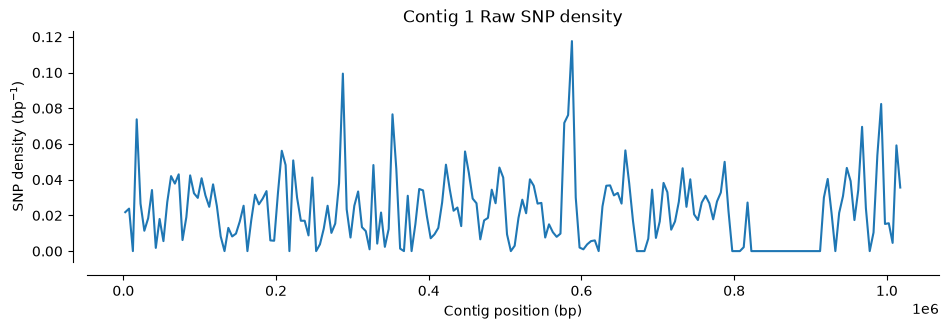

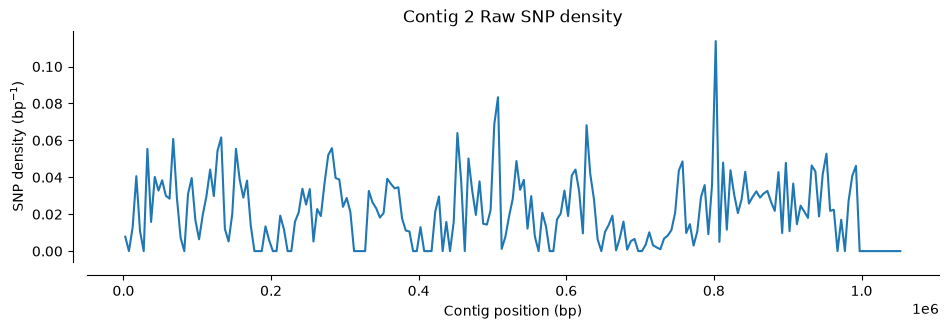

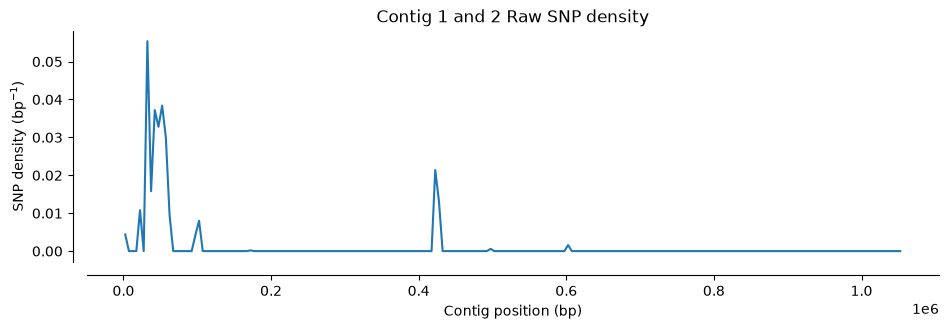

In [12]:
#Plot SNP density
plot_variant_density(Hifi_Contig_1_vcf, window_size=5000, title='Contig 1 Raw SNP density')
plot_variant_density(Hifi_Contig_2_vcf, window_size=5000, title='Contig 2 Raw SNP density')
plot_variant_density(Hifi_Contig_1_2_vcf, window_size=5000, title='Contig 1 and 2 Raw SNP density')

We can also plot some of the most relevant parameters from the VCF files, such as read depth and  quality, to have an overview of the quality of the SNPs in these samples. We defined for that the function `plot_variant_hist` in the file `../Scripts/pythonScripts.sh`.

We can plot the metrics "DP" (Read depth),  "QUAL" (Quality score), and "MQ" (Mapping quality) for `Hifi_Contig1_vcf`. 
The x-axis shows the metric value, the y-axis shows how many SNPs have that value. Notice that most SNPs have high quality scores.


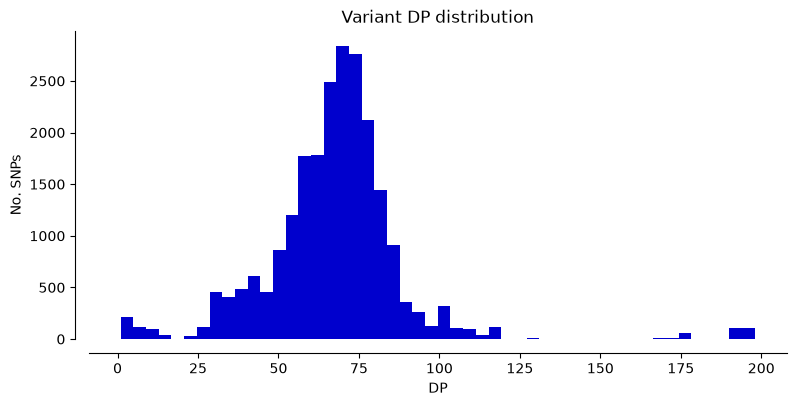

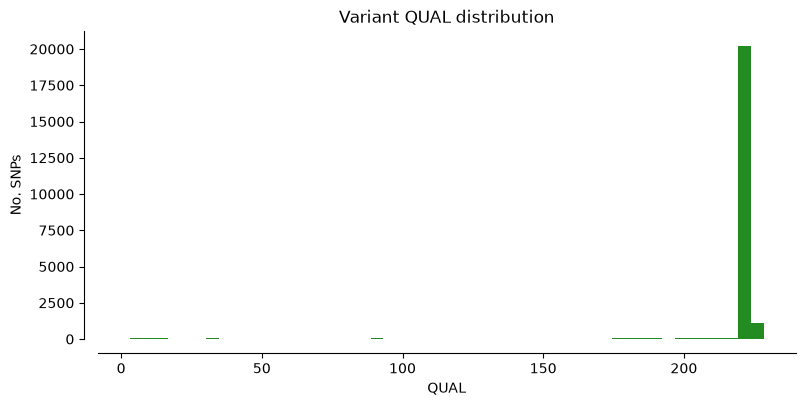

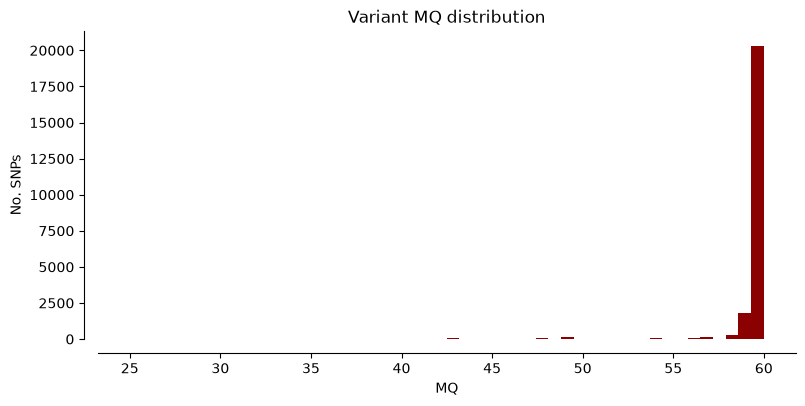

In [13]:
plot_variant_hist(Hifi_Contig_1_vcf,'DP', "mediumblue")
plot_variant_hist(Hifi_Contig_1_vcf, 'QUAL', "forestgreen")
plot_variant_hist(Hifi_Contig_1_vcf, 'MQ', "darkred")

:::{.callout-tip title="Task T1"}
In the two cells below generate the same three plots as above using the VCF files for Contig 2 and Contig 1+2.

You will just need to copy the three command lines from the cell above and replace the name of the VCF files.
:::

In [ ]:
#Plot the metrics for Contig 2

In [ ]:
#Plot the metrics for Contig 1 + 2

:::{.callout-tip title="Task T2"}
The plots show some SNPs with low read depth and low quality—these are likely false positives. We'll filter the VCF files to remove them.

We'll use `bcftools filter` with the `-i` flag to set quality thresholds. The example below shows all zero values for which variants to keep, but adjust them based on what you see in your plots.

The command **to modify with the thresholds are below**.
:::

In [15]:
%%bash

bcftools filter -i '(QUAL>0) & (DP > 0) & (MQ > 0)' results/VCF_Files/HIFI_Contig_1.vcf -O v > results/VCF_Files/HIFI_Contig_1_filtered.vcf
bcftools filter -i '(QUAL>0) & (DP > 0) & (MQ > 0)' results/VCF_Files/HIFI_Contig_2.vcf -O v > results/VCF_Files/HIFI_Contig_2_filtered.vcf
bcftools filter -i '(QUAL>0) & (DP > 0) & (MQ > 0)' results/VCF_Files/HIFI_Contig_1_2.vcf -O v > results/VCF_Files/HIFI_Contig_1_2_filtered.vcf

[W::bcf_hdr_check_sanity] MQ should be declared as Type=Float
[W::bcf_hdr_check_sanity] MQ should be declared as Type=Float
[W::bcf_hdr_check_sanity] MQ should be declared as Type=Float



--------------

We read the filtered VCF file for Contig1 in python and generate the same plots as before. We can read the VCF file and generate all the plots in one cell this time.

We check how many positions have been eliminated by the filter and compare the plots with the ones for the unfiltered VCFs.

If you consider that there are still positions with with low quality you can change the filter and repeat the process.

/opt/course/.pixi/envs/default/lib/python3.12/site-packages/allel/io/vcf_read.py:1732: UserWarning: invalid INFO header: '##INFO=<ID=VDB,Number=1,Type=Float,Description="Variant Distance Bias for filtering splice-site artefacts in RNA-seq data (bigger is better)",Version="3">\n'
  warnings.warn('invalid INFO header: %r' % header)


Number of SNPs in Contig 1 VCF filtered file: 22918


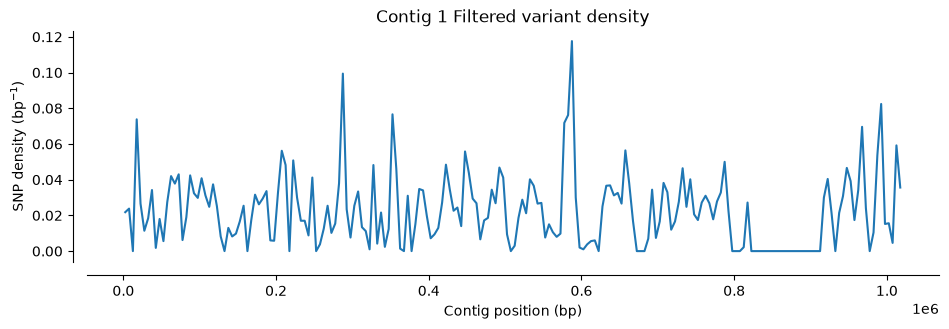

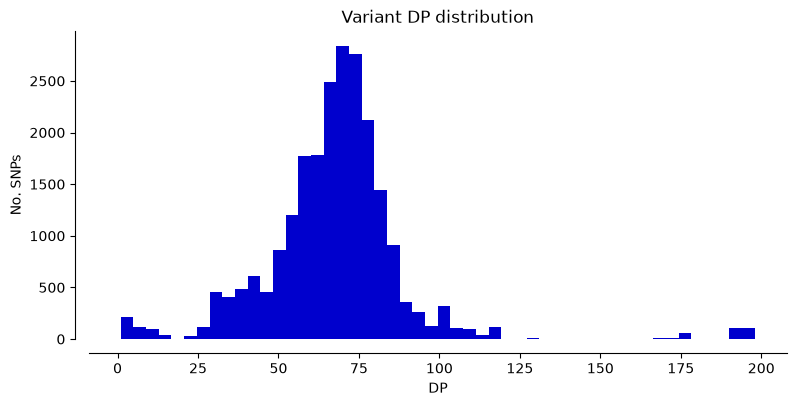

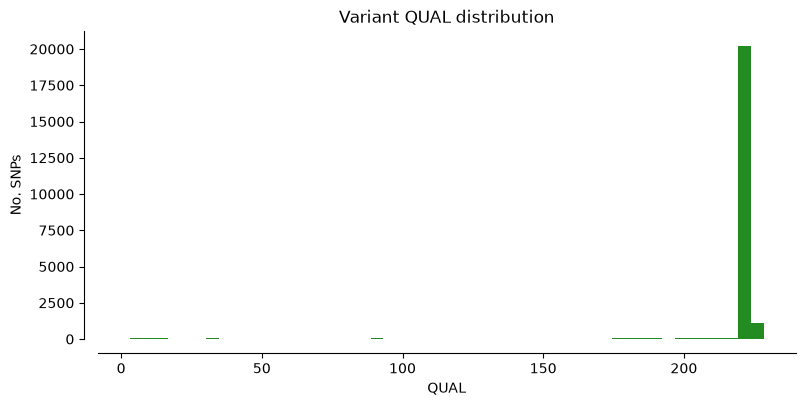

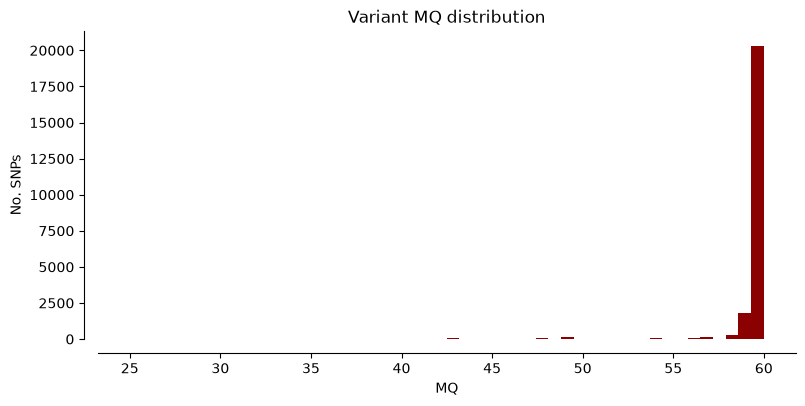

In [16]:
Hifi_Contig1_filtered = allel.read_vcf('results/VCF_Files/HIFI_Contig_1_filtered.vcf', fields='*')

print("Number of SNPs in Contig 1 VCF filtered file:", Hifi_Contig1_filtered['variants/POS'].size)

#Plot SNP density
plot_variant_density(Hifi_Contig1_filtered, window_size=5000, title='Contig 1 Filtered variant density')
#Plot metrics
plot_variant_hist(Hifi_Contig1_filtered,'DP',  "mediumblue")
plot_variant_hist(Hifi_Contig1_filtered, 'QUAL',  "forestgreen")
plot_variant_hist(Hifi_Contig1_filtered, 'MQ', "darkred")

:::{.callout-tip title="Task T3"}
**This task covers the rest of the notebook and contains explanations as well**. The code will work only if you complete correctly the empty cells. Some cells are filled in to help.

* In the two cells below generate the same plots as above using the filtered VCF files for Contig 2 and Contig 1 + 2.  You will just need to copy the three command lines from the cell above and replace the name of the VCF files.

In [ ]:
#Figures for Contig 2 Filtered VCF


In [ ]:
#Figures for Contig 1 + 2 Filtered VCF



Below we repeat the quality check and filtering as described above for the two RNA-seq VCF files:

- Read the VCF files in Python:

In [19]:
vcf_S10_RNA = allel.read_vcf('results/VCF_Files/RNA_S10_merged.vcf', fields='*')
vcf_Ti_RNA = allel.read_vcf('results/VCF_Files/RNA_TI_merged.vcf', fields='*')

- Print the number of SNPs in the two RNA-seq VCF files. Note that the number of SNPs is much smaller than for the Hifi VCF files. Also, there is a difference in the number of SNPs for the two genotypes. As S10 RNA-seq data originates from the same genotype as the referece genome, one would expect a small number of SNPs to be identified in this case. 

In [20]:
print("Number of SNPs in S10 RNA-seq VCF file:", vcf_S10_RNA['variants/POS'].size)
print("Number of SNPs in Ti RNA-seq VCF file:", vcf_Ti_RNA['variants/POS'].size)

Number of SNPs in S10 RNA-seq VCF file: 108
Number of SNPs in Ti RNA-seq VCF file: 3411


- Generate SNP density plots using the plot_variant_density() function:

In [ ]:
#code here

In [ ]:
#code here

- Generate info histograms using the plot_variant_hist() function for the same fields. 
You should observe that the metrics for the RNA-seq vcf files are quite different from the ones using Hifi reads.

In [ ]:
#code here

In [ ]:
#code here

- Filter the VCF files using `bcftools` and your selected tresholds after inspecting the VCF files.
**Add the filter thresholds before running the command.**

In [ ]:
%%bash

bcftools view -i 'add filter thresholds here' results/VCF_Files/RNA_S10_merged.vcf -O v > results/VCF_Files/RNA_S10_merged_filtered.vcf
bcftools view -i 'add filter thresholds here' results/VCF_Files/RNA_TI_merged.vcf -O v > results/VCF_Files/RNA_TI_merged_filtered.vcf

- Read the filtered VCFs in python:

In [ ]:
vcf_S10_RNA_filtered = allel.read_vcf('results/VCF_Files/RNA_S10_merged_filtered.vcf', fields='*')
vcf_Ti_RNA_filtered = allel.read_vcf('results/VCF_Files/RNA_TI_merged_filtered.vcf', fields='*')

- Check the number of SNPs in the filtered VCF files:

In [ ]:
print("Number of SNPs in the filtered S10 RNA-seq VCF file:", vcf_S10_RNA_filtered['variants/POS'].size)
print("Number of SNPs in the filtered Ti RNA-seq VCF file:", vcf_Ti_RNA_filtered['variants/POS'].size)

- Plot same histograms for the filtered VCF files.

In [ ]:
#code here

In [ ]:
#code here

:::{.callout-tip title="Question"}
- Q4. Is it relevant to filter for false positives in this case, and what parameters  would you look further into?
:::

# Genotypes counting

We want to count the different genotypes in each of the five filtered VCF files generated previously. To make this task easier we can take advantage of the counting functions in the `scikit-allel`  package. We have used those to implement a little function called `position_count` in the file `../Scripts/pythonScripts.sh`.

* You can then use the function with each of the 5 filtered VCF files to count the number of positions. You need to fill the names of the VCF files imported in Python.

In [21]:
#Contig 1 filtered VCF
position_count(Hifi_Contig1_filtered)

Count missing positions: 0
Count heterozygous positions: [21569]
Count homozygous reference positions: [0]
Count homozygous alternate positions: [1349]


In [ ]:
#Contig 2 filtered VCF
position_count()

In [ ]:
#Contig 1 and 2 filtered VCF
position_count()

In [ ]:
#RNAseq S10 filtered VCF
position_count()

In [ ]:
#RNAseq Ti filtered VCF
position_count()

**End of the task**

:::

---

# Comparison of VCF files 

Compare the VCF files with subgenome variants and the VCF files with S10/Tienshan genotype specific variants obtained from RNA-seq mapping

We want now to find overlapping position between the Contig 1 and Contig 2 Hifi VCF files and the Ti RNAseq VCF file. 

To ease this task we will first create two merged VCF files containing:


*   Hifi Contig 1 VCF + Ti RNAseq VCF
*   Hifi Contig 2 VCF + Ti RNAseq VCF

Once again, we will use `bcftools` for this task, using the merge function. However, the `bcftools merge`  function works only with compressed and indexed VCF files, so first we will do this. 


In [ ]:
%%bash

bcftools view results/VCF_Files/HIFI_Contig_1_filtered.vcf -Oz -o results/VCF_Files/HIFI_Contig_1_filtered.vcf.gz
bcftools index results/VCF_Files/HIFI_Contig_1_filtered.vcf.gz -f -o results/VCF_Files/HIFI_Contig_1_filtered.vcf.gz.csi

bcftools view results/VCF_Files/HIFI_Contig_2_filtered.vcf -Oz -o results/VCF_Files/HIFI_Contig_2_filtered.vcf.gz
bcftools index results/VCF_Files/HIFI_Contig_2_filtered.vcf.gz -f -o results/VCF_Files/HIFI_Contig_2_filtered.vcf.gz.csi

bcftools view results/VCF_Files/RNA_TI_merged_filtered.vcf -Oz -o results/VCF_Files/RNA_TI_merged_filtered.vcf.gz
bcftools index results/VCF_Files/RNA_TI_merged_filtered.vcf.gz -f -o results/VCF_Files/RNA_TI_merged_filtered.vcf.gz.csi

Now we can merge Contig 1 VCF with the Ti RNA VCF and keep only positions that match between the two files by filtering out any positions with missing genotypes.

In [ ]:
%%bash

bcftools merge results/VCF_Files/HIFI_Contig_1_filtered.vcf.gz results/VCF_Files/RNA_TI_merged_filtered.vcf.gz | bcftools filter -e 'GT="./."' > results/VCF_Files/TI_Contig_1_merged.vcf

Merge Contig 2 VCF with the Ti RNA VCF and keep only positions that match between the two files.

In [ ]:
%%bash

bcftools merge results/VCF_Files/HIFI_Contig_2_filtered.vcf.gz results/VCF_Files/RNA_TI_merged_filtered.vcf.gz | bcftools filter -e 'GT="./."' > results/VCF_Files/TI_Contig_2_merged.vcf

Take a look at the merged VCF file.
<br>
You can see that compared with the VCF files for just one sample, there is now a new column in the file, with the corresponding genotype for the second sample that we merged.

In [ ]:
%%bash

cat results/VCF_Files/TI_Contig_1_merged.vcf | head -50

In order to count the genotypes for the matching positions we can use once again `bcftools filter`  command. Only that this time we will filter based on the genotype columns for the two samples (GT[0] and GT[1]). GT[0] repesents the genotype for the first sample in the merge command and GT[1] is the genotype for the second sample in the merge command.  

*   AR - heterozygous
*   AA - homozygous alternate

For example, the filter `GT[0]="AR" && GT[1]="AR"` will keep only position in which both samples have a heterozygous genotype.
A quick way to count how many positions are in the VCF file is by suing the simple bash command `grep`. This will count all the lines in the VCF files that do not start with a `#`, thus all the data lines. 

In [ ]:
%%bash 

echo "AR + AR:"
bcftools filter  -i 'GT[0]="AR" && GT[1]="AR"' results/VCF_Files/TI_Contig_1_merged.vcf | grep -c -v "^#"
echo "AR + AA:"
bcftools filter  -i 'GT[0]="AR" && GT[1]="AA"' results/VCF_Files/TI_Contig_1_merged.vcf | grep -c -v "^#"
echo "AA + AR:"
bcftools filter  -i 'GT[0]="AA" && GT[1]="AR"' results/VCF_Files/TI_Contig_1_merged.vcf | grep -c -v "^#"
echo "AA + AA:"
bcftools filter  -i 'GT[0]="AA" && GT[1]="AA"' results/VCF_Files/TI_Contig_1_merged.vcf | grep -c -v "^#"

:::{.callout-tip title="Task T4"}
Use the same commands as above to count the positions marching the filters in the `Contig2_Ti_merged.vcf`.
:::

In [ ]:
#code here

:::{.callout-note title="Wrapping up"}

In this exercise, you identified polymorphisms between the two white clover subgenomes using Hifi reads alignment files and SNPs specific for the white clover Tienshan genotype using RNA-seq alignment files. You learned how to import VCF files in Python to extract data and created plots. You also filtered low-quality variants from the VCF files and counted genotypes. 

:::
